Decision Tree Accuracy: 0.8
Random Forest Accuracy: 0.9853658536585366
Cross Validation Score: 0.9970731707317073
cp          0.135072
ca          0.127327
thalach     0.122169
oldpeak     0.121905
thal        0.110518
age         0.077908
chol        0.074822
trestbps    0.071171
exang       0.057594
slope       0.045782
sex         0.028731
restecg     0.018557
fbs         0.008444
dtype: float64


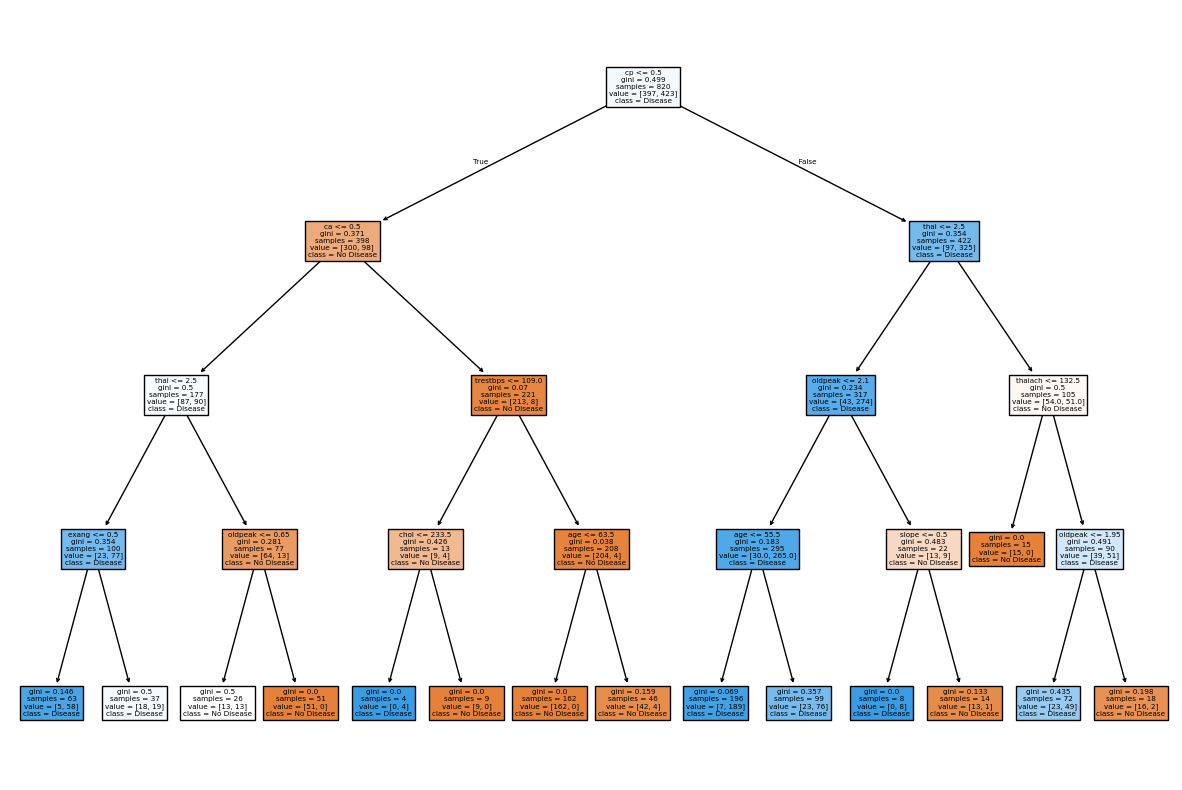

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

df = pd.read_csv("heart.csv")

X = df.drop("target", axis=1)
y = df["target"]


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)


print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
scores = cross_val_score(rf, X, y, cv=5)
print("Cross Validation Score:", scores.mean())
importance = pd.Series(rf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))
plt.figure(figsize=(15,10))
plot_tree(dt, feature_names=X.columns, class_names=["No Disease","Disease"], filled=True)
plt.savefig("tree.png")
plt.show()